In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('e_commerce_final_table.csv')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,product_id,seller_id,price,freight_value,product_category_name,review_score,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,4.0,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumaria,4.0,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,automotivo,5.0,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,pet_shop,5.0,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,papelaria,5.0,santo andre,SP


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 113120 entries, 0 to 113119
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113120 non-null  str    
 1   customer_id                    113120 non-null  str    
 2   order_status                   113120 non-null  str    
 3   order_purchase_timestamp       113120 non-null  str    
 4   order_delivered_customer_date  110653 non-null  str    
 5   product_id                     113120 non-null  str    
 6   seller_id                      113120 non-null  str    
 7   price                          113120 non-null  float64
 8   freight_value                  113120 non-null  float64
 9   product_category_name          111510 non-null  str    
 10  review_score                   94571 non-null   float64
 11  customer_city                  113120 non-null  str    
 12  customer_state                 113120 non

,price,freight_value,review_score
count,113120.000000,113120.000000,94571.000000
mean,120.533605,19.983259,4.031003
std,183.402097,15.790782,1.389347
min,0.850000,0.000000,1.000000
25%,39.900000,13.080000,4.000000
50%,74.900000,16.260000,5.000000
75%,134.900000,21.150000,5.000000
max,6735.000000,409.680000,5.000000


In [4]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

In [5]:
df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

In [6]:
df['total_price'] = df['price'] + df['freight_value']

In [7]:
df.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_delivered_customer_date     2467
product_id                           0
seller_id                            0
price                                0
freight_value                        0
product_category_name             1610
review_score                     18549
customer_city                        0
customer_state                       0
delivery_time                     2467
total_price                          0
dtype: int64

In [8]:
df = df[df['delivery_time'].notna()]

In [9]:
df['review_score'] = df['review_score'].fillna(df['review_score'].median())

In [10]:
df = df[df['order_status'] == 'delivered']

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 110646 entries, 0 to 113119
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110646 non-null  str           
 1   customer_id                    110646 non-null  str           
 2   order_status                   110646 non-null  str           
 3   order_purchase_timestamp       110646 non-null  datetime64[us]
 4   order_delivered_customer_date  110646 non-null  datetime64[us]
 5   product_id                     110646 non-null  str           
 6   seller_id                      110646 non-null  str           
 7   price                          110646 non-null  float64       
 8   freight_value                  110646 non-null  float64       
 9   product_category_name          109103 non-null  str           
 10  review_score                   110646 non-null  float64       
 11  customer_city   

In [12]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,product_id,seller_id,price,freight_value,product_category_name,review_score,customer_city,customer_state,delivery_time,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,4.0,sao paulo,SP,8.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumaria,4.0,barreiras,BA,13.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,automotivo,5.0,vianopolis,GO,9.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,pet_shop,5.0,sao goncalo do amarante,RN,13.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,papelaria,5.0,santo andre,SP,2.0,28.62


In [13]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df.groupby('order_month')['total_price'].sum().reset_index()

monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

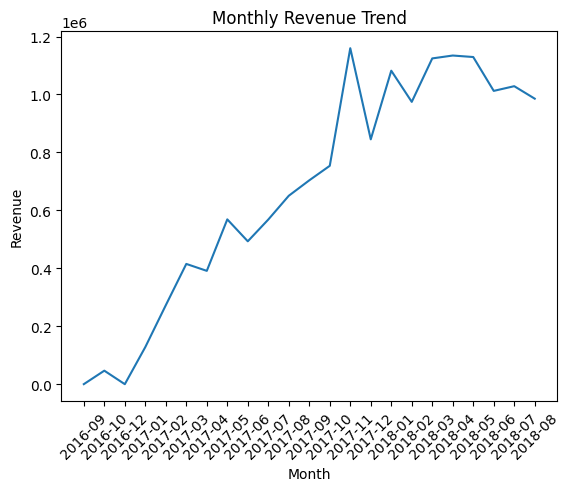

In [14]:
plt.figure()
plt.plot(monthly_revenue['order_month'], monthly_revenue['total_price'])
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

In [15]:
monthly_revenue.to_csv('monthly_revenue.csv', index=False)

In [16]:
category_revenue = df.groupby('product_category_name')['total_price'].sum().reset_index()

category_revenue = category_revenue.sort_values(by='total_price', ascending=False)

category_revenue.head(10)

,product_category_name,total_price
11,beleza_saude,1415213.61
66,relogios_presentes,1264338.09
13,cama_mesa_banho,1236999.02
32,esporte_lazer,1122220.55
44,informatica_acessorios,1038773.26
54,moveis_decoracao,885459.45
72,utilidades_domesticas,760422.03
26,cool_stuff,693348.68
8,automotivo,670779.08
40,ferramentas_jardim,568428.85


In [17]:
category_revenue.head(10).to_csv('top_categories.csv', index=False)

In [18]:
df['delivery_time'].describe()

count    110646.000000
mean         12.010873
std           9.445793
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time, dtype: float64

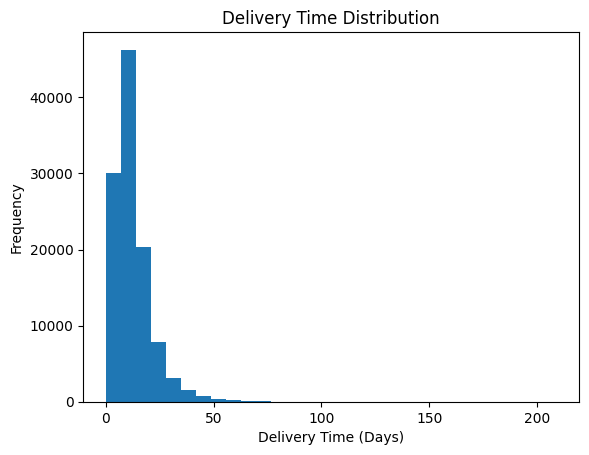

In [19]:
plt.figure()
plt.hist(df['delivery_time'], bins=30)
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Frequency')
plt.show()

In [20]:
df[['delivery_time']].to_csv('delivery_time.csv', index=False)

In [21]:
review_delivery = df.groupby('review_score')['delivery_time'].mean().reset_index()
review_delivery

,review_score,delivery_time
0,1.0,19.106769
1,2.0,15.185126
2,3.0,13.621765
3,4.0,11.773933
4,5.0,10.702933


In [22]:
review_delivery.to_csv('review_delivery.csv', index=False)

In [23]:
customer_spend = df.groupby('customer_id')['total_price'].sum().reset_index()

In [25]:
customer_spend.describe()

,total_price
count,96470.000000
mean,160.345749
std,219.460164
min,9.590000
25%,62.010000
50%,105.370000
75%,176.870000
max,13664.080000


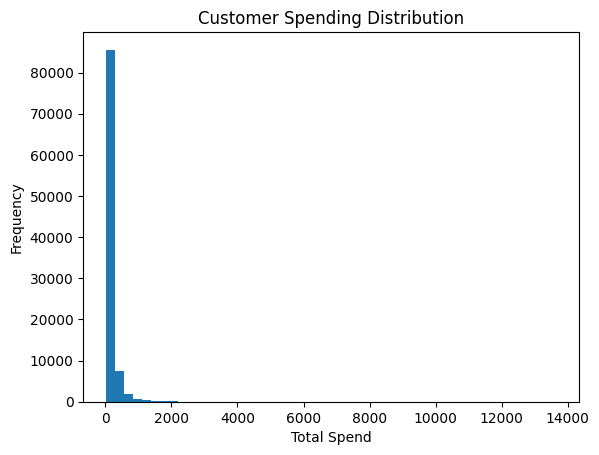

In [29]:
plt.figure()
plt.hist(customer_spend['total_price'], bins=50)
plt.title('Customer Spending Distribution')
plt.xlabel('Total Spend')
plt.ylabel('Frequency')
plt.show()

In [30]:
customer_spend.to_csv('customer_spend.csv', index=False)